In [2]:
import pandas as pd
import numpy as np

%matplotlib inline
# matplotlib.use('TkAgg')  # or 'QtAgg', etc.

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee'])

# Increase fonts globally (adjust sizes as needed)
# DEFAULT IS 12
plt.rcParams.update({
    'font.size': 15,            # default text size
    'axes.titlesize': 15,      # axes title
    'axes.labelsize': 15,      # x/y labels
    'xtick.labelsize': 15,     # x tick labels
    'ytick.labelsize': 15,     # y tick labels
    'legend.fontsize': 15,     # legend text
    'figure.titlesize': 15
})

In [3]:
# Import data
df_command = pd.read_csv('data/log_25_2025-10-21-21-56-06_vehicle_command_0.csv')
df_actuator_motors = pd.read_csv('data/log_25_2025-10-21-21-56-06_actuator_motors_0.csv')

In [4]:
t_com = (df_command['timestamp'] - df_command['timestamp'][0]) / 1e6
com = df_command['command']
t_act = (df_actuator_motors['timestamp'] - df_actuator_motors['timestamp'][0]) / 1e6
control1 = df_actuator_motors['control[1]']
control2 = df_actuator_motors['control[2]']
control3 = df_actuator_motors['control[3]']
control4 = df_actuator_motors['control[4]']

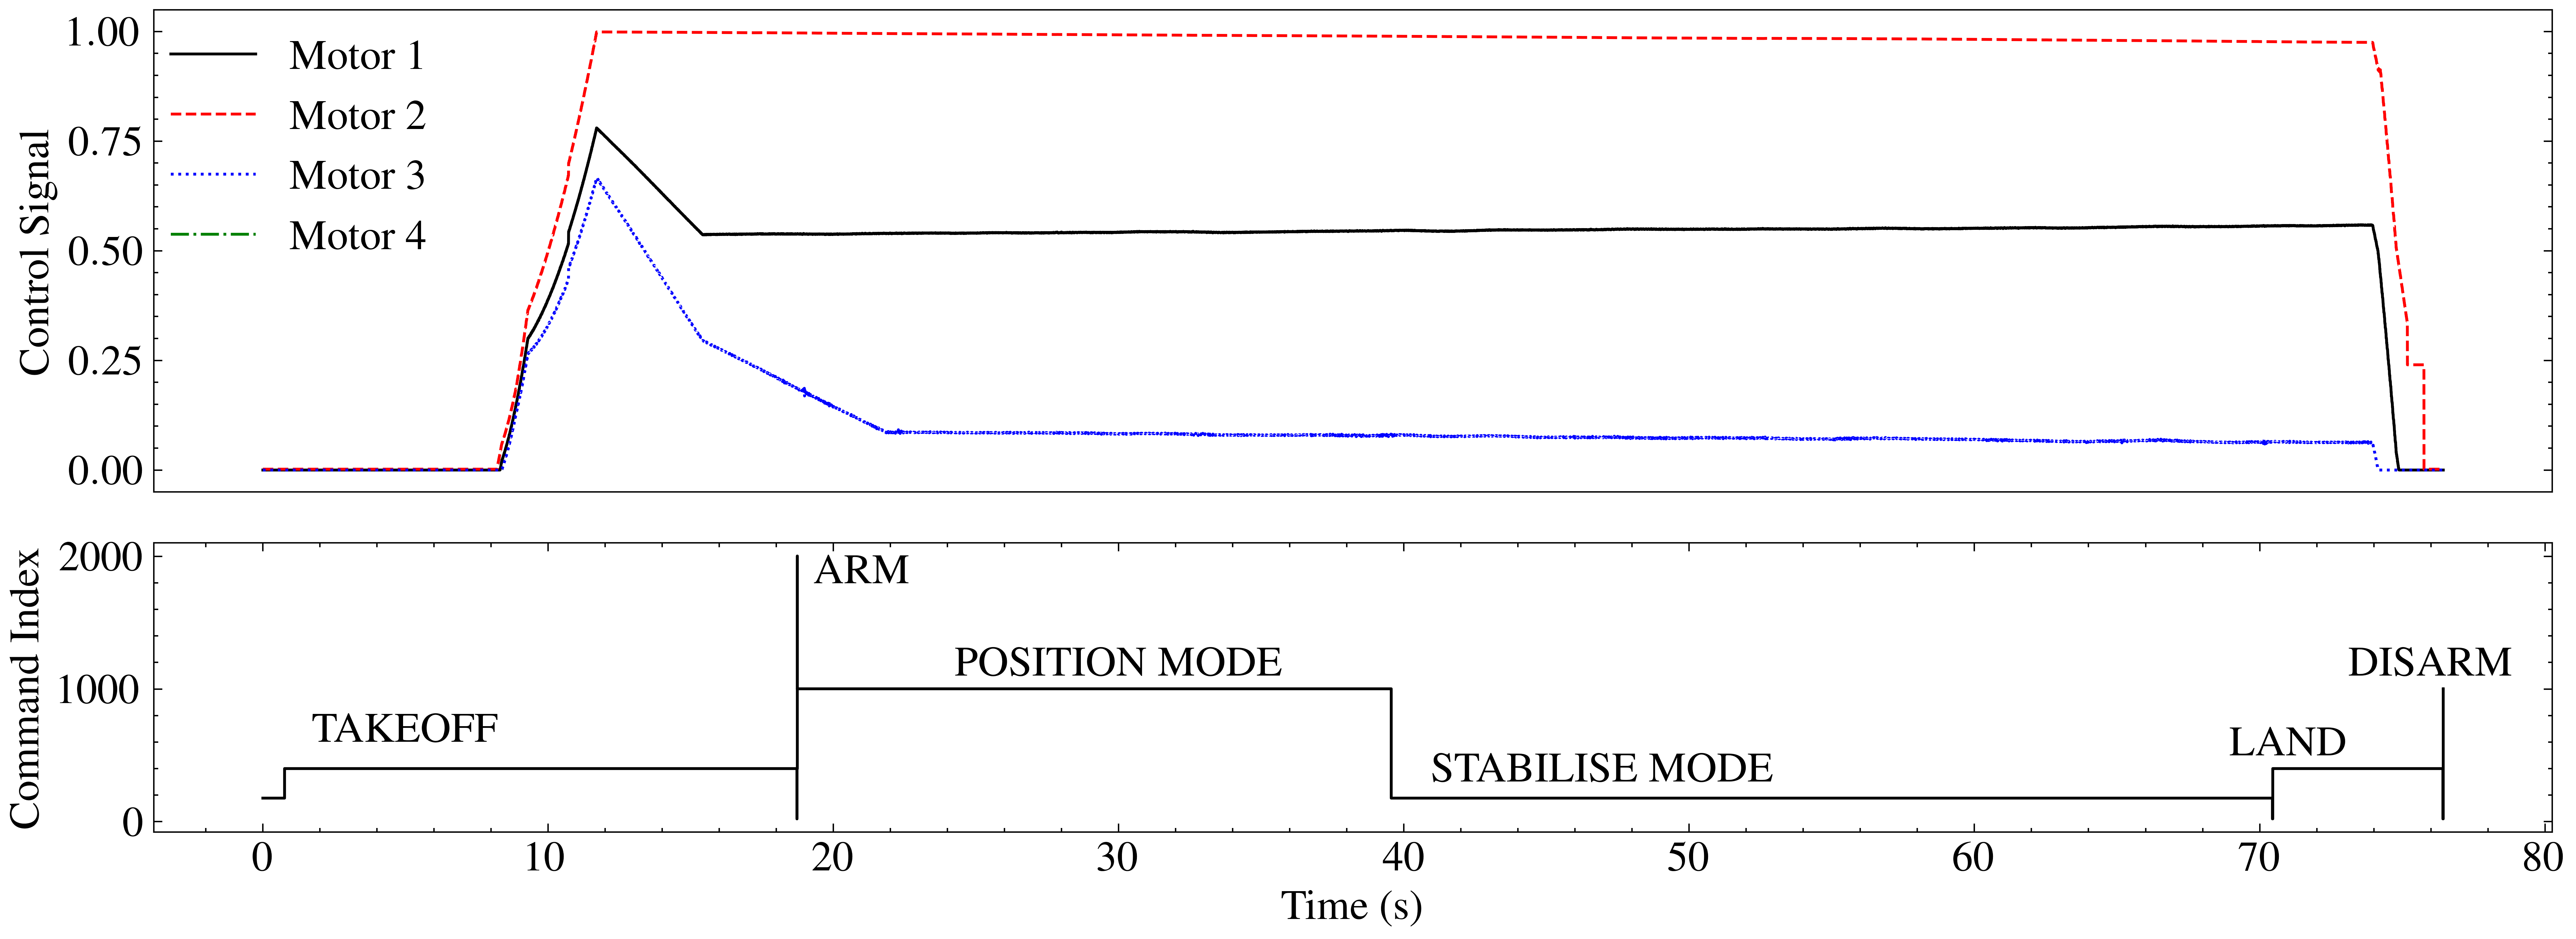

In [5]:
# Create a figure and subplots with specified width and height ratios
fig, axs = plt.subplots(2, 1, figsize=(13, 5),
                        gridspec_kw={'width_ratios': [1], 'height_ratios': [1.5, 0.9]})

# Plot on the subplots
axs[0].plot(t_act, control1, label='Motor 1')
axs[0].plot(t_act, control2, label='Motor 2')
axs[0].plot(t_act, control3, label='Motor 3')
axs[0].plot(t_act, control4, label='Motor 4')
axs[0].xaxis.set_visible(False)
axs[0].set_ylabel('Control Signal')
axs[0].legend(loc=(0,0.45))

axs[1].step(t_com, com, label='Command', color='black', where='post')
axs[1].set_ylabel('Command Index')
axs[1].set_xlabel('Time (s)')
axs[1].text(5, 600, "TAKEOFF", fontsize=15, color='k', ha='center')
axs[1].text(21, 1800, "ARM", fontsize=15, color='k', ha='center')
axs[1].text(30, 1100, "POSITION MODE", fontsize=15, color='k', ha='center')
axs[1].text(47, 300, "STABILISE MODE", fontsize=15, color='k', ha='center')
axs[1].text(71, 500, "LAND", fontsize=15, color='k', ha='center')
axs[1].text(76, 1100, "DISARM", fontsize=15, color='k', ha='center')
plt.tight_layout() # Adjust layout to prevent overlapping
plt.savefig("actuation_1.pdf", bbox_inches='tight')
plt.show()

# Arm
# Change mode
# Land
# Disarm